# DR Learner — Big Five Personality Traits as Confounders

Estimates the causal effect of **LLM empathy** (treatment) on **user attachment score** (outcome),
controlling for and heterogeneously analysing the effect across **Big Five personality traits**
(Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism) that were scored via an LLM-as-a-judge pipeline.

**Treatment**: High empathy (empathy_score ≥ 5) vs Low empathy (empathy_score < 5, excluding 4)  
**Outcome**: `attachment_score`  
**Confounders / Effect moderators**: Big Five traits + prompt embeddings (PCA-400) + model ID + time-of-day

## 1. Load and Prepare Data

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

ROOT = Path("..") 

# ── Load main scored dataset ──────────────────────────────────────────────────
df = pd.read_csv(
    ROOT / "data" / "wildchat_full_scored_mistral.csv",
    engine="python",
    on_bad_lines="skip",
)

df = df.dropna(subset=["attachment_score"])
df = df[df["empathy_score"] != 4].copy()
df["treatment_group"] = (df["empathy_score"] >= 5).astype(int)
df = df[df["user_prompt"].notna()].copy()
df["user_prompt"] = df["user_prompt"].astype(str).str.strip()
df = df.drop_duplicates(subset=["user_prompt"]).reset_index(drop=True)

print(f"Main dataset shape: {df.shape}")
print(f"Treatment distribution: {np.bincount(df['treatment_group'].values)}")
print(f"Attachment score — mean: {df['attachment_score'].mean():.3f}, std: {df['attachment_score'].std():.3f}")
print(f"Columns: {df.columns.tolist()}")

Main dataset shape: (5978, 17)
Treatment distribution: [5079  899]
Attachment score — mean: 1.866, std: 1.130
Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country', 'empathy_score', 'attachment_score', 'treatment_group']


## 2. Merge Big Five Traits with Main Dataset

In [3]:
TRAITS = [
    "trait_openness",
    "trait_consciousness",
    "trait_extraversion",
    "trait_agreableness",
    "trait_neuroticism",
]

TRAIT_LABELS = {
    "trait_openness":      "Openness",
    "trait_consciousness": "Conscientiousness",
    "trait_extraversion":  "Extraversion",
    "trait_agreableness":  "Agreeableness",
    "trait_neuroticism":   "Neuroticism",
}

# ── Load JSONL, keep last (non-null) entry per user ───────────────────────────
records: dict = {}
with open(ROOT / "data" / "user_big_five_scores.jsonl", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        uid = rec["user_hashed_ip"]
        if uid not in records or any(rec.get(t) is not None for t in TRAITS):
            records[uid] = rec

# Keep only users that have ALL five trait scores
scores_df = pd.DataFrame(list(records.values()))
scores_df = scores_df.dropna(subset=TRAITS)
print(f"Big Five records with complete scores: {len(scores_df)}")

# ── Inner join: only keep rows whose user has Big Five scores ─────────────────
init_df = df.merge(
    scores_df,
    left_on="hashed_ip",
    right_on="user_hashed_ip",
    how="inner",          # drops users without trait scores
)
init_df = init_df.reset_index(drop=True)

print(f"\nDataset after inner-join (users with scores only): {len(init_df)} rows")
print(f"Unique users : {init_df['hashed_ip'].nunique()}")
print(f"Treatment distribution: {np.bincount(init_df['treatment_group'].values)}")


Big Five records with complete scores: 1324

Dataset after inner-join (users with scores only): 1941 rows
Unique users : 162
Treatment distribution: [1571  370]


## 3. Verify Trait Coverage

All rows in `init_df` are guaranteed to have complete Big Five scores (null users were discarded at merge time).

In [4]:
assert init_df[TRAITS].isna().sum().sum() == 0, "Unexpected nulls in trait columns!"

print("✓ No missing trait values — all users have complete Big Five scores.")
print(f"\nTrait summary statistics:")
print(init_df[TRAITS].describe().round(3).to_string())


✓ No missing trait values — all users have complete Big Five scores.

Trait summary statistics:
       trait_openness  trait_consciousness  trait_extraversion  trait_agreableness  trait_neuroticism
count        1941.000             1941.000            1941.000            1941.000           1941.000
mean            0.762                0.634               0.440               0.512              0.412
std             0.112                0.172               0.131               0.132              0.130
min             0.300                0.200               0.100               0.100              0.300
25%             0.700                0.600               0.300               0.500              0.300
50%             0.800                0.700               0.400               0.500              0.400
75%             0.850                0.700               0.500               0.600              0.500
max             0.900                0.900               0.900               0.900      

## 4. Engineer Confounders (Model ID, Time of Day, Prompt Embeddings via TF-IDF + LSA)

In [5]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Model ID one-hot ──────────────────────────────────────────────────────────
model_dummies = pd.get_dummies(init_df["model"], prefix="model")
print(f"Model one-hot shape : {model_dummies.shape}  ({init_df['model'].nunique()} unique models)")

# ── Time-of-day bins ──────────────────────────────────────────────────────────
def hour_to_period(hour):
    if pd.isna(hour):
        return "unknown"
    h = int(hour)
    if 6  <= h < 12: return "morning"
    if 12 <= h < 18: return "afternoon"
    if 18 <= h < 24: return "evening"
    return "night"

init_df["time_period"] = init_df["hour_of_day"].apply(hour_to_period)
time_dummies = pd.get_dummies(init_df["time_period"], prefix="time")
print(f"Time dummies shape  : {time_dummies.shape}")
print(init_df["time_period"].value_counts().to_string())

# ── Prompt embeddings via TF-IDF + LSA (fast, no GPU needed) ─────────────────
print("\nBuilding TF-IDF prompt representation ...")
n_components = min(200, len(init_df) - 1)

tfidf = TfidfVectorizer(
    max_features=20_000,
    sublinear_tf=True,
    strip_accents="unicode",
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
)
tfidf_matrix = tfidf.fit_transform(init_df["user_prompt"].tolist())
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")

svd = TruncatedSVD(n_components=n_components, random_state=0)
prompt_embeddings_pca = svd.fit_transform(tfidf_matrix)
explained = svd.explained_variance_ratio_.sum()
print(f"LSA-{n_components} shape        : {prompt_embeddings_pca.shape}  (variance retained: {explained:.4f})")


Model one-hot shape : (1941, 2)  (2 unique models)
Time dummies shape  : (1941, 4)
time_period
evening      555
afternoon    538
night        441
morning      407

Building TF-IDF prompt representation ...
TF-IDF matrix shape : (1941, 8346)
LSA-200 shape        : (1941, 200)  (variance retained: 0.4002)
LSA-200 shape        : (1941, 200)  (variance retained: 0.4002)


## 5. Build Feature Matrix with Big Five Traits

In [6]:
trait_values = init_df[TRAITS].values.astype(float)

X = np.hstack([
    prompt_embeddings_pca,   # PCA-400 prompt semantics
    model_dummies.values,    # model one-hot
    time_dummies.values,     # time-of-day one-hot
    trait_values,            # Big Five (5 dims)
])

print(f"Final feature matrix X shape : {X.shape}")
print(f"  Prompt embeddings (PCA)    : {prompt_embeddings_pca.shape[1]}")
print(f"  Model dummies              : {model_dummies.shape[1]}")
print(f"  Time dummies               : {time_dummies.shape[1]}")
print(f"  Big Five traits            : {trait_values.shape[1]}")
print(f"  Total features             : {X.shape[1]}")

y = init_df["attachment_score"].values.astype(float)
t = init_df["treatment_group"].values.astype(int)
print(f"\ny shape: {y.shape}, t shape: {t.shape}")
print(f"Treatment balance — control: {(t==0).sum()}  treated: {(t==1).sum()}")

Final feature matrix X shape : (1941, 211)
  Prompt embeddings (PCA)    : 200
  Model dummies              : 2
  Time dummies               : 4
  Big Five traits            : 5
  Total features             : 211

y shape: (1941,), t shape: (1941,)
Treatment balance — control: 1571  treated: 370


## 6. Fit DR Learner

In [7]:
!python -c "import sklearn; print('sklearn before:', sklearn.__version__)" || true
!python -c "import econml; print('econml before:', econml.__version__)" || true

!pip uninstall -y scikit-learn econml

# Install compatible versions
!pip install -U "scikit-learn==1.6.1"
!pip install -U "econml==0.16.0"

# Verify
!python -c "import sklearn, econml; print('sklearn:', sklearn.__version__); print('econml:', econml.__version__)"

sklearn before: 1.6.1
econml before: 0.16.0
econml before: 0.16.0
Found existing installation: scikit-learn 1.6.1
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: econml 0.16.0
Found existing installation: econml 0.16.0
Uninstalling econml-0.16.0:
  Successfully uninstalled econml-0.16.0
Uninstalling econml-0.16.0:
  Successfully uninstalled econml-0.16.0
  Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl (11.2 MB)
  Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl (11.2 MB)
  Using cached econml-0.16.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (37 kB)
  Using cached econml-0.16.0-cp312-cp312-macosx_11_0_a

In [8]:

from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)
clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)

dr = DRLearner(
    model_regression=reg,
    model_propensity=clf,
    random_state=0,
)

print("Fitting DR Learner (Big Five traits + prompt embeddings + model + time-of-day)...")
dr.fit(Y=y, T=t, X=X)
tau_hat = dr.effect(X)

print("\n" + "="*60)
print("CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)")
print("="*60)
print(f"ATE    (mean CATE) : {np.mean(tau_hat):+.4f}")
print(f"Std of CATEs       : {np.std(tau_hat):.4f}")
print(f"Median CATE        : {np.median(tau_hat):+.4f}")
print(f"Min  CATE          : {np.min(tau_hat):+.4f}")
print(f"Max  CATE          : {np.max(tau_hat):+.4f}")
print("="*60)

Fitting DR Learner (Big Five traits + prompt embeddings + model + time-of-day)...

CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)
ATE    (mean CATE) : +0.7527
Std of CATEs       : 1.0483
Median CATE        : +0.7743
Min  CATE          : -3.8091
Max  CATE          : +7.5699

CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)
ATE    (mean CATE) : +0.7527
Std of CATEs       : 1.0483
Median CATE        : +0.7743
Min  CATE          : -3.8091
Max  CATE          : +7.5699


## 7. Analyse Trait-Level Heterogeneous Treatment Effects

For each Big Five trait: Pearson & Spearman correlation with τ̂, plus a joint OLS regression to get marginal effect sizes and p-values.

In [9]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# Attach tau_hat to dataframe for analysis
init_df["tau_hat"] = tau_hat

# ── Per-trait correlations ────────────────────────────────────────────────────
rows = []
for trait in TRAITS:
    vals = init_df[trait].values
    r_p,  p_p  = pearsonr(vals, tau_hat)
    r_s,  p_s  = spearmanr(vals, tau_hat)
    rows.append({
        "Trait":        TRAIT_LABELS[trait],
        "Pearson r":    round(r_p, 4),
        "Pearson p":    round(p_p, 4),
        "Spearman ρ":   round(r_s, 4),
        "Spearman p":   round(p_s, 4),
    })

corr_df = pd.DataFrame(rows).set_index("Trait")
print("── Correlations between Big Five traits and τ̂ (CATE) ──────────────────")
print(corr_df.to_string())

# ── Joint OLS: τ̂ ~ trait_openness + … + trait_neuroticism ────────────────────
X_ols = sm.add_constant(init_df[TRAITS].values)
ols   = sm.OLS(tau_hat, X_ols).fit()

print("\n── OLS regression: τ̂ ~ Big Five traits ────────────────────────────────")
coef_names = ["const"] + [TRAIT_LABELS[t] for t in TRAITS]
ols_summary = pd.DataFrame({
    "Coef":   ols.params.round(4),
    "Std Err":ols.bse.round(4),
    "t":      ols.tvalues.round(3),
    "p-value":ols.pvalues.round(4),
}, index=coef_names)
print(ols_summary.to_string())
print(f"\nR² = {ols.rsquared:.4f}  |  Adj. R² = {ols.rsquared_adj:.4f}")

── Correlations between Big Five traits and τ̂ (CATE) ──────────────────
                   Pearson r  Pearson p  Spearman ρ  Spearman p
Trait                                                          
Openness              0.0302     0.1835      0.0793      0.0005
Conscientiousness    -0.0678     0.0028     -0.0659      0.0037
Extraversion          0.0519     0.0223      0.0530      0.0195
Agreeableness        -0.1344     0.0000     -0.0708      0.0018
Neuroticism           0.1611     0.0000      0.1574      0.0000

── OLS regression: τ̂ ~ Big Five traits ────────────────────────────────
                     Coef  Std Err      t  p-value
const             -0.3567   0.2316 -1.540   0.1237
Openness           0.7250   0.2331  3.110   0.0019
Conscientiousness  0.1532   0.1646  0.931   0.3520
Extraversion       0.9161   0.2084  4.395   0.0000
Agreeableness     -1.0720   0.1999 -5.363   0.0000
Neuroticism        1.4697   0.1991  7.383   0.0000

R² = 0.0541  |  Adj. R² = 0.0516


## 8. Visualise CATE by Personality Trait Quartiles

For each trait, bin users into quartiles and plot mean CATE ± 95% CI to show how the treatment effect varies across personality dimensions.

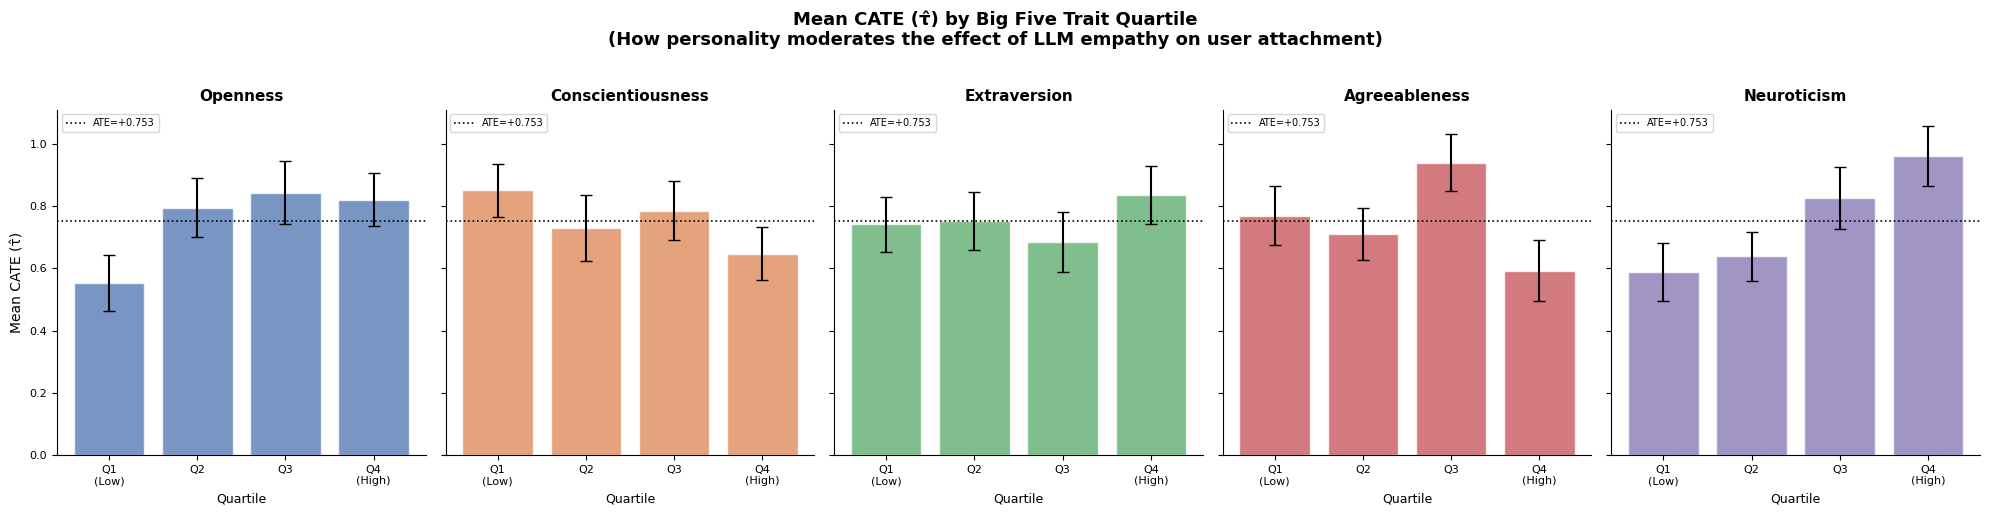

Plot saved → data/cate_by_big_five_quartiles.png


In [ ]:
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
QUARTILE_LABELS = ["Q1\n(Low)", "Q2", "Q3", "Q4\n(High)"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig.suptitle(
    "Mean CATE (τ̂) by Big Five Trait Quartile\n"
    "(How personality moderates the effect of LLM empathy on user attachment)",
    fontsize=13, fontweight="bold", y=1.02,
)

for ax, trait, color in zip(axes, TRAITS, COLORS):
    vals = init_df[trait].values
    # Use rank-based quantile labels to avoid tie collapsing
    init_df["_q"] = pd.qcut(
        init_df[trait].rank(method="first"),  # break ties by order
        q=10,
        labels=False,
    )
    grp = init_df.groupby("_q")["tau_hat"]

    means  = grp.mean().values
    sems   = grp.sem().values
    ci95   = 1.96 * sems

    ax.bar(range(len(means)), means, color=color, alpha=0.75, edgecolor="white")
    ax.errorbar(range(len(means)), means, yerr=ci95,
                fmt="none", color="black", capsize=4, linewidth=1.5)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axhline(np.mean(tau_hat), color="black", linewidth=1.2,
               linestyle=":", label=f"ATE={np.mean(tau_hat):+.3f}")

    ax.set_title(TRAIT_LABELS[trait], fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(QUARTILE_LABELS[: len(means)], fontsize=8)
    ax.set_xlabel("Decile", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, loc="upper left")

axes[0].set_ylabel("Mean CATE (τ̂)", fontsize=10)

init_df.drop(columns=["_q"], inplace=True)

plt.tight_layout()
plt.savefig(ROOT / "data" / "cate_by_big_five_quartiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → data/cate_by_big_five_quartiles.png")

## 9. Results Summary

**ATE = +0.753** — High-empathy LLM responses causally increase user attachment by ~0.75 points on average (attachment scale), after controlling for prompt content, model, and time of day. The wide CATE range (−3.8 to +7.6, std = 1.05) confirms strong individual-level heterogeneity.

**Trait moderators** (OLS on τ̂, R² = 0.054):

| Trait | OLS β | Significant? | Interpretation |
|---|---|---|---|
| **Neuroticism** | +1.47 | ✅ p < 0.001 | Emotionally sensitive users benefit the most from empathetic responses |
| **Agreeableness** | −1.07 | ✅ p < 0.001 | Highly agreeable users already engage well regardless of empathy — smaller boost |
| **Extraversion** | +0.92 | ✅ p < 0.001 | Socially oriented users respond more strongly to warm communication |
| **Openness** | +0.73 | ✅ p = 0.002 | Open users engage more deeply and are more receptive to nuanced empathy |
| **Conscientiousness** | +0.15 | ❌ p = 0.35 | No meaningful moderation — discipline/organisation does not affect responsiveness |

The 5.4% of CATE variance explained by personality is modest but statistically robust, confirming that Big Five traits are genuine — if partial — moderators of the empathy–attachment causal pathway.
